<a href="https://colab.research.google.com/github/PreciousAkpokighe/AI-ML-Training-course-professional-programme-with-Imperial-College-London/blob/main/Self_study_try_it_activity_14_3_Using_soft_margin_classifiers_on_two_dimensional_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 14.3: Using soft-margin classifiers on two-dimensional data

A soft-margin classifier is a type of SVM that allows some misclassifications or margin violations to achieve a better balance between fitting the training data and generalising to unseen data. Unlike a hard-margin SVM, which requires that all data points be perfectly separated by the decision boundary (only suitable for linearly separable data), a soft-margin SVM introduces slack variables to permit some data points to fall within the margin or even on the wrong side of the hyperplane.

In this notebook, you will
- Train two soft-margin classifiers
- Derive the confusion matrix
- Visualise the decision boundary
- Compare the number of support vectors in each of the two soft-margin classifiers and estimate the classifier with more support vectors.

In [1]:
#Import the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import svm
import math
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Use the following to plot SVMs
from mlxtend.plotting import plot_decision_regions # On terminal, install: pip.install mlxtend

#### Task 1: SVM-based classifier on a non-separable data set
**Load the two-dimensional data `Case2linear/X.npy` that has 20 rows and two columns, and the corresponding target `Case2linear/y.np`.**

In [3]:
n = 20 # n points in each group
X = np.load('X.npy')
y = np.load('y.npy')

**Plot the two-dimensional points and colour them so that points with the same class have the same colour.**

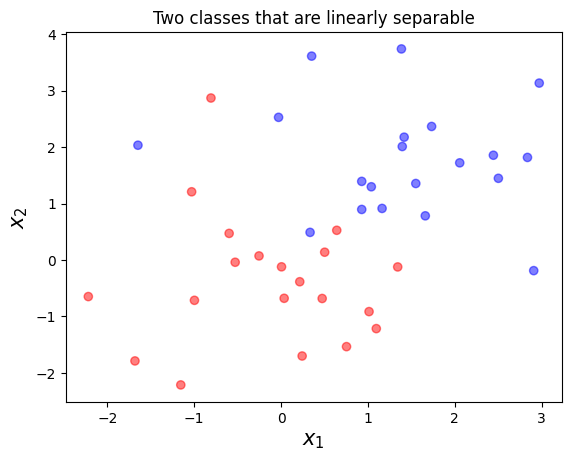

In [4]:
color = np.concatenate((np.repeat("red", n), np.repeat("blue",n)), axis=0) #y is split half-half
plt.scatter(X[:,0], X[:,1], c = color, alpha= .5)
plt.xlabel("$x_1$", size = 15)
plt.ylabel("$x_2$", size = 15)
plt.title("Two classes that are linearly separable")
plt.show()

## Question 1:

**Why might a linear hard-margin Support Vector Classifier (SVC) not be suitable for this data set?**

- Answer: The data set is not linearly separable, hence there is no perfect classifier. Thus, the hard-margin SVC will fail.

**Train a soft-margin linear SVC with associated cost $=1$, derive the confusion matrix, and visualise the decision boundary.**

In [5]:

clf_c1 = svm.SVC(kernel = 'linear', C = 1)
clf_c1.fit(X, y);

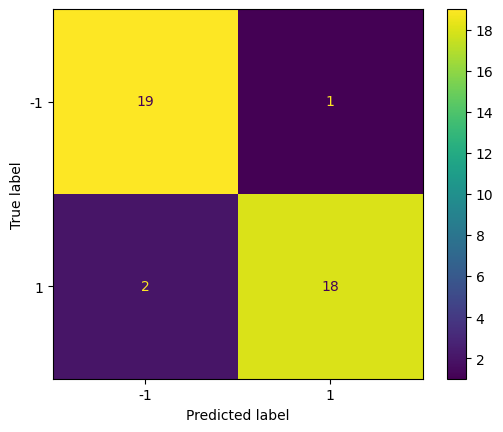

In [6]:
cm = confusion_matrix(y, clf_c1.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

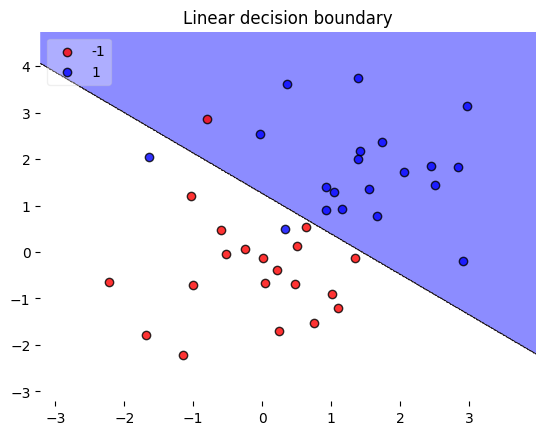

In [7]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when everything is classified the same.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf_c1, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

**Train a soft-margin linear SVC with associated cost $=0.01$, derive the confusion matrix, and visualise the decision boundary.**

In [8]:

clf_c001 = svm.SVC(kernel = 'linear', C = 0.01)
clf_c001.fit(X, y);

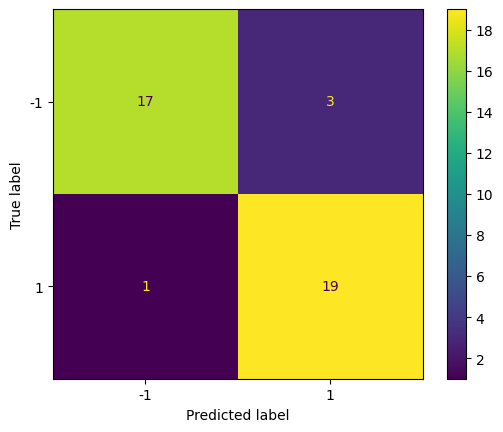

In [9]:
cm = confusion_matrix(y, clf_c001.predict(X))
cmd = ConfusionMatrixDisplay(cm, display_labels=np.unique(y))
cmd.plot();

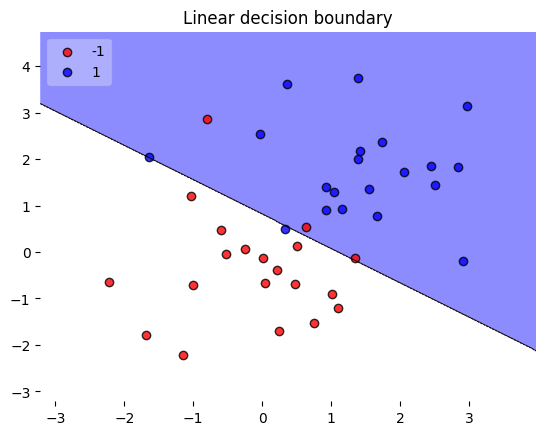

In [10]:
with warnings.catch_warnings(): #Otherwise, the package might throw an error that there is no "boundary" when everything is classified the same.
    warnings.simplefilter("ignore")
    plot_decision_regions(X, y, clf=clf_c001, legend=2, colors = "red,blue", markers= "o");
    ax=plt.gca();
    plt.title("Linear decision boundary")
    plt.show();

**Compare the number of support vectors of the previous two points**

Intuitively, support vectors are the points whose removal would cause the decision boundary to change. Recalling the bias–variance trade-off, you would expect a model with smaller variance to have more support vectors. Otherwise, if only a small number of points determine the boundary, removing just a few could change its shape significantly — making the model highly biased toward the training set.

Moreover, in soft-margin classification, increasing the associated cost will penalise misclassification more, hence the SVC will be forced to be biased. You would therefore expect the number of support vectors to decrease with increasing cost. Use `clf.support_vectors_` attribute of `sklearn.svm` to compare the numbers.

In [11]:
support_vectors_c1=np.shape(clf_c1.support_vectors_)[0]

In [12]:
support_vectors_c2=np.shape(clf_c001.support_vectors_)[0]

## Question 2:

Based on the number of support vectors, which of the classifiers might be a more suitable option?

**Answer:**

When comparing two soft classifiers (such as soft-margin SVMs), the number of support vectors can provide insight into the model's performance and generalisation ability, but it is not a direct measure of which classifier is "better" without additional context.

If both classifiers have similar performance metrics (e.g., accuracy, precision, recall), then the classifier with fewer support vectors is generally preferred due to its simplicity and likely better generalisation.